In [112]:
# Import Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import sklearn.model_selection as ms
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import feature_selection as fs


In [113]:
data = pd.read_csv(r'/Users/abhishekkanade/Documents/PDQA/data_cleaned.csv')
data.head()

,country,year,cereal_yield,fdi_perc_gdp,en_per_gdp,en_per_cap,co2_ttl,co2_per_cap,co2_per_gdp,pop_urb_aggl_perc,prot_area_perc,gdp,gni_per_cap,under_5_mort_rate,pop_growth_perc,pop,urb_pop_growth_perc,urb_pop
0,AGO,1991,417.4,5.449515,179.271884,565.451027,4367.397,0.409949,129.971142,15.290728,12.399822,1.219375e+10,820.0,239.1,3.034866,10653515.0,6.687032,4099472.572
1,AGO,1992,397.0,4.982460,193.632183,550.548264,4418.735,0.401597,141.244823,15.660630,12.399823,5.779394e+09,470.0,235.3,3.226990,11002910.0,6.750459,4385759.926
2,AGO,1993,267.8,5.715529,266.318379,551.688878,5801.194,0.510141,246.261769,16.025739,12.399823,5.285600e+09,310.0,231.1,3.297243,11371750.0,6.700777,4689709.700
3,AGO,1994,298.4,4.195018,260.830190,541.553067,3890.687,0.331321,159.575256,16.065941,12.399824,4.059577e+09,190.0,226.3,3.212170,11742960.0,6.503667,5004849.552
4,AGO,1995,402.2,9.374417,237.623934,528.386164,11012.001,0.909699,409.106543,16.134424,12.399825,5.039535e+09,320.0,221.5,3.037335,12105105.0,6.223936,5326246.200


In [114]:
random_state = 0

***
### Overview of the available data

In [115]:
print(f"Shape of the data : {data.shape}")

Shape of the data : (1700, 18)


In [116]:
print(f"available columns  and their data types : \n{data.dtypes}")

available columns  and their data types : 
country                 object
year                     int64
cereal_yield           float64
fdi_perc_gdp           float64
en_per_gdp             float64
en_per_cap             float64
co2_ttl                float64
co2_per_cap            float64
co2_per_gdp            float64
pop_urb_aggl_perc      float64
prot_area_perc         float64
gdp                    float64
gni_per_cap            float64
under_5_mort_rate      float64
pop_growth_perc        float64
pop                    float64
urb_pop_growth_perc    float64
urb_pop                float64
dtype: object


### Handeling Outlier

In [117]:
# remove the ARE outlier

data = data[data['country'] != 'ARE']

print(f"Shape of the data after removing outlier : {data.shape}")

Shape of the data after removing outlier : (1686, 18)


In [118]:
# Choose features and label columns
feature_cols = ['cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap',
                'pop_urb_aggl_perc', 'prot_area_perc', 'pop_growth_perc', 'urb_pop_growth_perc']
label_col = ['co2_per_cap']

# convert into numpy arrays (required for sklearn model)

features = np.array(data[feature_cols])
labels = np.array(data[label_col])


In [119]:
features

array([[ 417.4       ,    5.44951458,  820.        , ...,   12.39982205,
           3.03486601,    6.68703163],
       [ 397.        ,    4.98245985,  470.        , ...,   12.39982269,
           3.22698986,    6.75045876],
       [ 267.8       ,    5.71552893,  310.        , ...,   12.39982333,
           3.29724265,    6.70077708],
       ...,
       [1816.1       ,    5.7538601 ,  620.        , ...,   35.98301766,
           2.47931167,    2.8785138 ],
       [1907.9       ,   11.47085026,  750.        , ...,   35.98301766,
           2.56491884,    2.96253368],
       [2144.        ,    6.41099075,  970.        , ...,   35.98301766,
           2.65395608,    3.0499962 ]])

### Train-Test Split and Cross-Validation

In [120]:
np.random.seed(1)
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.2, random_state=random_state)

### Feature Selection with Cross-Validation

In [145]:
np.random.seed(1)
# Set folds for cross validation for the feature slection

feature_folds = ms.KFold(n_splits= 4 ,shuffle= True , random_state=random_state)

# Define the model

rf_selector = RandomForestRegressor(random_state=random_state)

# Define an object fro a model for recursive feature elimination with cv
np.random.seed(1)
selector = fs.RFECV(estimator = rf_selector , cv = feature_folds, scoring='r2', n_jobs=1)

selector = selector.fit(features_train, np.ravel(labels_train))

selector.support_

print("Features ranking after RFECV : ")
print(selector.ranking_)

# Print the important features
ranks_transform = list(np.transpose(selector.ranking_))
chosen_features = [ i for i , j in zip(feature_cols , ranks_transform) if j == 1 ]
print('Chosen important features : ')
print(chosen_features)

Features ranking after RFECV : 
[1 2 1 1 1 1 1 1]
Chosen important features : 
['cereal_yield', 'gni_per_cap', 'en_per_cap', 'pop_urb_aggl_perc', 'prot_area_perc', 'pop_growth_perc', 'urb_pop_growth_perc']


In [122]:
# Reduce features
features_train_reduced = selector.transform(features_train)
features_test_reduced = selector.transform(features_test)


print("Training subset shape before the recursive feature elimination: ",features_train.shape)
print("Training subset array shape after the recursive feature elimination: ", features_train_reduced.shape)
print("Test subset array shape after the recursive feature elimination: ",features_test_reduced.shape)

Training subset shape before the recursive feature elimination:  (1348, 8)
Training subset array shape after the recursive feature elimination:  (1348, 7)
Test subset array shape after the recursive feature elimination:  (338, 7)



### Hyperparameter tuning



In [123]:
# define value range for hyperparameter tuning
n_estimators = [int(x) for x in np.linspace(200,2000,10)]

max_depth = [ int(x) for x in np.linspace(10,100,11)]
max_depth.append(None)

# Create hyperparameter grid
param_grid = {
    'n_estimators' : n_estimators,
    'max_features' : ['sqrt', 'log2', None],
    'max_depth' : max_depth,
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}           # Number of trees in the forest

In [124]:
# define the cross-validation folds for the hyperparameter tuning
np.random.seed(1)
inside_folds = ms.KFold(n_splits=5, shuffle = True, random_state=random_state)

# Define the random forest regressor model object
rf_tuner = RandomForestRegressor(random_state=random_state)

# Perform a randomized search on the grid
np.random.seed(1)
rf_model = ms.RandomizedSearchCV(estimator=rf_tuner, param_distributions = param_grid,
                                 random_state=random_state, refit=True,
                                 cv=inside_folds, scoring = 'r2', return_train_score=True, n_jobs=-1)

In [125]:
# Fit the grid search model object with cross-validation on the data
rf_model.fit(features_train_reduced, np.ravel(labels_train))

# Corrected variable name
print("Best Parameters:", rf_model.best_params_)

Best Parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 28}


In [127]:
# pick the model with the best hyperparameter combination for further analysis
rf_best_model = rf_model.best_estimator_

### Evaluation of the model with the best hyperparameters on the training subset with cross-validation

In [128]:
'''The random forest model object *rf_best_model* with 
the most important features and the most suitable hyperparameters
 will be now evaluated on the training subset with cross-validation 
 first:'''

np.random.seed(1)
outside_folds = ms.KFold(n_splits=10, shuffle=True, random_state=random_state)

# Evaluate the model on the training subset with cross-validation
cv_eval = cross_val_score(rf_best_model, features_train_reduced, labels_train, cv = outside_folds, n_jobs=-1)

print('Mean R2 score of all CV folds = %4.3f' % np.mean(cv_eval))
print('Standard deviation of the R2 score over all folds = %4.3f' % np.std(cv_eval))
print('R2 score for each fold:')

# print the R2 score for each fold
for i, j in enumerate(cv_eval):
    print('Fold %2d    %4.3f' % (i+1, j))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklea

Mean R2 score of all CV folds = 0.986
Standard deviation of the R2 score over all folds = 0.003
R2 score for each fold:
Fold  1    0.990
Fold  2    0.990
Fold  3    0.989
Fold  4    0.985
Fold  5    0.981
Fold  6    0.984
Fold  7    0.986
Fold  8    0.987
Fold  9    0.986
Fold 10    0.984


#### Cross-Validation Results

The model achieved strong and consistent performance across all folds:

- **Mean R² score (10 folds):** 0.984  
- **Standard deviation:** 0.003 




### Validate the model on the testing subset

In [130]:
predictions = rf_best_model.predict(features_test_reduced)

r2 = r2_score(labels_test, predictions)
print('R2 score on the test subset = %4.3f' % r2)
mse = mean_squared_error(labels_test, predictions)
print('Mean Squared Error on the test subset = %4.3f' % mse)
rmse = np.sqrt(mse)
print('Root Mean Squared Error on the test subset = %4.3f' % rmse)

R2 score on the test subset = 0.986
Mean Squared Error on the test subset = 0.272
Root Mean Squared Error on the test subset = 0.522


### Model Evaluation & Prediction Quality

The obtained R² score of **0.986** may seem optimistic at first. However, several steps were taken to reduce overfitting and improve generalization:

- Dataset split with **80% used for training**
- **Cross-validation** during feature selection, hyperparameter tuning, and model training

Note: **MSE and RMSE** values are not directly comparable to the dependent variable (CO₂ per capita), which ranges from **0 to 20 tons**.

To further evaluate performance, a **regression plot** is used to visualize predicted vs. actual CO₂ emissions per capita from the test set.


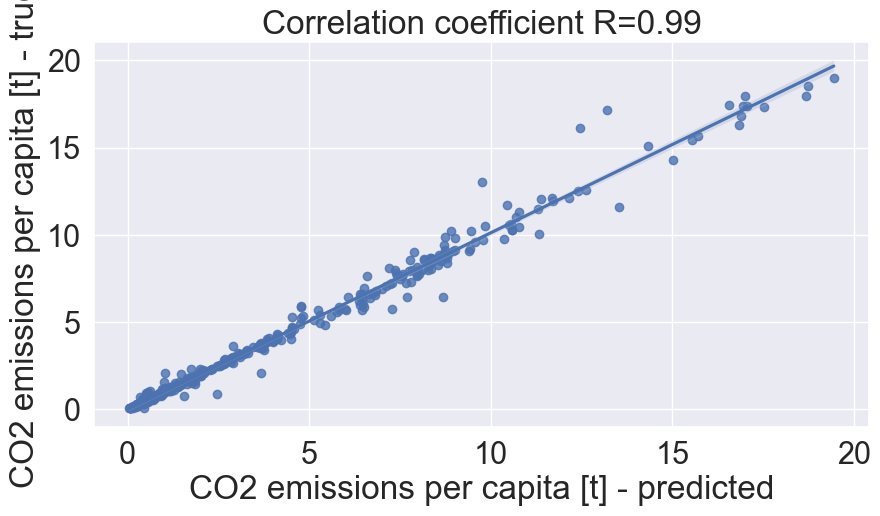

In [131]:
import seaborn as sns
# plot predicted vs true values of the test subset

f,ax=plt.subplots(figsize=(10,5))
sns.set_theme(font_scale=2)

sns.regplot(x=predictions, y=np.transpose(labels_test)[0,:], fit_reg=True)
plt.xlabel("CO2 emissions per capita [t] - predicted")
plt.ylabel("CO2 emissions per capita [t] - true")
plt.title("Correlation coefficient R="+str(round(np.corrcoef(predictions,np.transpose(labels_test)[0,:])[0,1],2)))
plt.show()

In [ ]:
import joblib
# Save the trained model to file
joblib.dump(rf_best_model, 'forecasting_co2_emmision.pkl')
print("Model saved to 'forecasting_co2_emmision.pkl")

Model saved to 'forecasting_co2_emmision.pkl


In [133]:
# Load model from file
load_model = joblib.load('forecasting_co2_emmision.pkl')
print("📂 Model loaded successfully.")

📂 Model loaded successfully.


### Calculating Compound Annual Growth Rates (CAGR) for Key Features

To assess long-term trends in country-level development indicators, we compute the **Compound Annual Growth Rate (CAGR)** for each of the selected features:

- `cereal_yield`
- `gni_per_cap`
- `en_per_cap`
- `pop_urb_aggl_perc`
- `prot_area_perc`
- `pop_growth_perc`
- `urb_pop_growth_perc`

The process involves:
- Filtering the dataset for a predefined list of selected countries.
- Sorting the data by year for each country.
- Calculating the CAGR for each feature based on its value in the earliest and latest available years.
- Skipping entries where data is missing, invalid, or where the time range is insufficient.

This analysis helps identify whether each feature has increased or decreased over time in each country, offering insights into national trends that may impact CO₂ emissions.

The final output displays feature-wise growth rates (in percentages) for each country in the form:



In [139]:
# List of selected features
selected_features = ['cereal_yield', 'gni_per_cap', 'en_per_cap',
                     'pop_urb_aggl_perc', 'prot_area_perc',
                     'pop_growth_perc', 'urb_pop_growth_perc']
# selected_features = chosen_features

In [140]:
selected_countries = ['IND' , 'CHN' , 'PAK' , 'ISR' , 'IRN']

df_filtered = data[data['country'].isin(selected_countries)]

growth_rates = {}

for country in selected_countries:
    country_data = df_filtered[(data['country'] == country)].sort_values('year')

    start_year = country_data['year'].min()
    end_year = country_data['year'].max()
    years = end_year - start_year

    country_growth = {}

    if years  <= 0:
        print(f"Skipping {country} due to insufficient year range.")
        continue

    for feature in selected_features:
        start_value = country_data[country_data['year'] == start_year][feature].values

        end_value = country_data[country_data['year'] == end_year][feature].values

        if len(start_value) == 0 or len(end_value) == 0:
            continue
        start_value = start_value[0]
        end_value = end_value[0]    

        if start_value <= 0 or end_value <= 0 or not np.isfinite(start_value) or not np.isfinite(end_value):
            continue

        cagr = (end_value / start_value) ** (1/years) - 1
        country_growth[feature] = cagr  # Convert to percentage

    growth_rates[country] = country_growth
        
        


/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1174/358787171.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  country_data = df_filtered[(data['country'] == country)].sort_values('year')
/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1174/358787171.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  country_data = df_filtered[(data['country'] == country)].sort_values('year')
/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1174/358787171.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  country_data = df_filtered[(data['country'] == country)].sort_values('year')
/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1174/358787171.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  country_data = df_filtered[(data['country'] == country)].sort_values('year')
/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1

In [141]:
# Display the calculated growth rates in a readable format
print("\nGrowth Rates (CAGR) from {} to {}:\n".format(start_year, end_year))

# Loop through each country and its corresponding growth rate dictionary
for country, features in growth_rates.items():
    print(f"{country}")  # Print the country name with an icon

    # Loop through each feature and its CAGR value
    for feature, rate in features.items():
        # Determine whether to display a plus or minus sign
        sign = '+' if rate >= 0 else '−'

        # Print the feature name and its growth rate percentage (formatted to two decimal places)
        print(f"  • {feature}: {sign}{abs(rate * 100):.2f}%")

    # Add a line break between countries for readability
    print()


Growth Rates (CAGR) from 1995 to 2008:

IND
  • cereal_yield: +1.94%
  • gni_per_cap: +6.85%
  • en_per_cap: +2.12%
  • pop_urb_aggl_perc: +1.26%
  • prot_area_perc: +0.35%
  • pop_growth_perc: −2.28%
  • urb_pop_growth_perc: −1.26%

CHN
  • cereal_yield: +1.60%
  • gni_per_cap: +13.58%
  • en_per_cap: +4.60%
  • pop_urb_aggl_perc: +3.71%
  • prot_area_perc: +1.19%
  • pop_growth_perc: −5.60%
  • urb_pop_growth_perc: −2.79%

PAK
  • cereal_yield: +2.29%
  • gni_per_cap: +5.00%
  • en_per_cap: +1.50%
  • pop_urb_aggl_perc: +0.84%
  • prot_area_perc: +0.01%
  • pop_growth_perc: −2.46%
  • urb_pop_growth_perc: −1.01%

ISR
  • cereal_yield: −0.46%
  • gni_per_cap: +4.60%
  • en_per_cap: +1.61%
  • pop_urb_aggl_perc: +0.24%
  • prot_area_perc: +0.51%
  • pop_growth_perc: −6.92%
  • urb_pop_growth_perc: −6.96%

IRN
  • cereal_yield: +0.03%
  • gni_per_cap: +9.57%
  • en_per_cap: +4.76%
  • pop_urb_aggl_perc: +0.05%
  • prot_area_perc: +1.89%
  • pop_growth_perc: −2.30%
  • urb_pop_growth_pe

### 📌 CAGR Analysis Summary (1991–2008)

1. **Economic Growth**
- All countries showed **positive GNI per capita growth**, **India (+6.85%)**, and **Pakistan/New Zealand (+5.00%)**, indicating strong economic progress.
2. **Agricultural Productivity**
- Cereal yields improved across the board, with **Pakistan (+2.29%)** reflecting better farming practices.
3. **Energy Use**
- **India and Pakistan** saw rising per capita energy use. 
4. **Urbanization & Demographics**
- Urban agglomeration increased moderately, while population and urban population growth rates declined, suggesting demographic shifts.
5. **Environmental Protection**
- Growth in protected areas was modest **India (+0.35%)** making the most progress.

Overall, the period saw economic and agricultural gains, mixed energy trends, slower population growth, and limited environmental advances.

### 🔮 Forecasting CO₂ Emissions per Capita (Next 20 Years)

This block of code projects future CO₂ emissions per capita for the selected countries using the following steps:

1. **Future Timeline Definition**  
   The forecast is made for the next 20 years beyond the latest year in the dataset.

2. **Base Year Feature Extraction**  
   For each country, the most recent complete feature row is extracted.

3. **Feature Growth Simulation**  
   Using previously calculated **Compound Annual Growth Rates (CAGR)**, each feature's value is incrementally grown year by year.

4. **CO₂ Prediction**  
   The pre-trained Random Forest model is used to predict CO₂ emissions per capita for each simulated future year, based on updated feature values.

5. **Results Compilation and Visualization**  
   - Forecasted results are stored and converted into a DataFrame.
   - A line plot displays the projected trends in CO₂ emissions per capita.
   - A preview of the last 5 forecasted years for India is shown in tabular format.


In [142]:
# Define the range of years to forecast (next 20 years beyond the last available year)
last_year = data['year'].max()
future_years = list(range(last_year + 1, last_year + 21))

In [143]:
# Initialize a list to store forecasted results
forecast_results = []

# Loop through each selected country for prediction
for country in selected_countries:
    country_data = data[(data['country'] == country)].sort_values('year')

    # Skip countries with missing feature values
    if country_data[selected_features].dropna().empty:
        print(f"Skipping {country} due to missing values.")
        continue

    # Take the latest complete record (most recent year) for the country
    latest_row = country_data[selected_features].dropna().iloc[-1].copy()

    # Forecast for each year into the future
    for year in future_years:
        # Apply the previously calculated CAGR to each feature
        for feature in selected_features:
            growth_rate = growth_rates.get(country, {}).get(feature, 0.0)
            latest_row[feature] *= (1 + growth_rate)

        # Use trained model to predict CO₂ emissions per capita
        input_features = latest_row.values.reshape(1, -1)
        predicted_co2 = load_model.predict(input_features)[0]

        # Store the forecast result
        forecast_results.append({
            'country': country,
            'year': year,
            'co2_percap': predicted_co2
        })

📈 Forecasted CO₂ Emissions per Capita (Next 20 Years)


/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1174/1766888276.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abhishekkanade/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


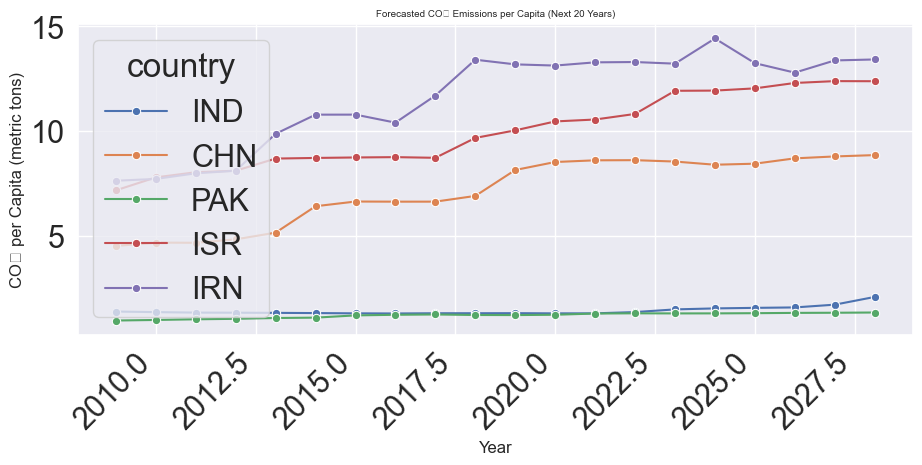


📊 Forecasted CO₂ per Capita for Last 5 Years in Forecast Period (India):

   country  year  co2_percap
15     IND  2024    1.540633
16     IND  2025    1.566713
17     IND  2026    1.587078
18     IND  2027    1.718929
19     IND  2028    2.086909


In [144]:
# Convert the list of predictions into a DataFrame
df_forecast = pd.DataFrame(forecast_results)

# Plot forecasted CO₂ per capita for all countries over the next 20 years
print('📈 Forecasted CO₂ Emissions per Capita (Next 20 Years)')
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_forecast, x='year', y='co2_percap', hue='country', marker='o')
plt.title('Forecasted CO₂ Emissions per Capita (Next 20 Years)', fontsize=7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO₂ per Capita (metric tons)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the forecast values for the last 5 years for India
print("\n📊 Forecasted CO₂ per Capita for Last 5 Years in Forecast Period (India):\n")
print(df_forecast[df_forecast['country'] == 'IND'].sort_values(by='year').tail(5))